In [1]:
import time
t1 = time.time()

import math
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[1], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-09-21 02:55:30.497287: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##### load data #####

HLdata_path = "/root/data/mucollider/two_boosted/3TeV/data_HLfeature.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

LLdata_path = "/root/data/mucollider/two_boosted/3TeV/data_LLfeature.h5"
LLdata_file = h5py.File(LLdata_path, 'r')
print(LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_everytype', 'target_sigbg']>
<KeysViewHDF5 ['particle_info']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'M_JJ', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

##### select BTag work point at WP70 (BitNumber 1) #####

BTag_leading = ((HLdata_file['BTag_leading'][:])&2)
BTag_subleading = ((HLdata_file['BTag_subleading'][:])&2)

##### include other high level features data #####

HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': HLdata.append(BTag_leading)
    elif feature=='BTag_subleading': HLdata.append(BTag_subleading)
    else: HLdata.append(HLdata_file[feature][:])
HLdata = np.array(HLdata).T
print('shape of high level data:', HLdata.shape)

LLdata = LLdata_file['particle_info'][:]
print('shape of low level data:', LLdata.shape)

target = HLdata_file['target_sigbg'][:]
print('shape of target:', target.shape)

#### Do training data and validation data split #####

HL_train, HL_val, LL_train, LL_val, y_train, y_val = train_test_split(HLdata, LLdata, target, test_size=0.2, random_state=2330, shuffle=True)
print("\nAfter training validation data split:")
print("HL training data: ", HL_train.shape, "HL validation data: ", HL_val.shape)
print("LL training data: ", LL_train.shape, "LL validation data: ", LL_val.shape)
print("training target: ", y_train.shape, "validation target: ", y_val.shape)

shape of high level data: (866059, 11)
shape of low level data: (866059, 160)
shape of target: (866059,)

After training validation data split:
HL training data:  (692847, 11) HL validation data:  (173212, 11)
LL training data:  (692847, 160) LL validation data:  (173212, 160)
training target:  (692847,) validation target:  (173212,)


In [4]:
##### construct model #####

### high level features part ###

HL_input = layers.Input(shape=(11,), name='HL_Input')

x_hl = layers.Dense(128)(HL_input)
x_hl = layers.BatchNormalization()(x_hl)
x_hl = layers.Activation('relu')(x_hl)
x_hl = layers.Dropout(0.1)(x_hl)

x_hl = layers.Dense(128)(x_hl)
x_hl = layers.BatchNormalization()(x_hl)
x_hl = layers.Activation('relu')(x_hl)
x_hl = layers.Dropout(0.1)(x_hl)

### low level features part ###

LL_input = layers.Input(shape=(160,), name='LL_Input')

x_ll = layers.Dense(512)(LL_input)
x_ll = layers.BatchNormalization()(x_ll)
x_ll = layers.Activation('relu')(x_ll)
x_ll = layers.Dropout(0.1)(x_ll)

x_ll = layers.Dense(128)(x_ll)
x_ll = layers.BatchNormalization()(x_ll)
x_ll = layers.Activation('relu')(x_ll)
x_ll = layers.Dropout(0.1)(x_ll)

### combine two parts of model and the following node ###

combined = layers.Concatenate()([x_hl, x_ll])

x = layers.Dense(256, activation='relu')(combined)
x = layers.Dense(16, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid', name='Output')(x)

model = models.Model(inputs=[HL_input, LL_input], outputs=output)

### optimizer ###

opt = keras.optimizers.Adam(learning_rate=1e-5)

### compile ###

model.compile(loss='binary_crossentropy', optimizer=opt, metrics=["accuracy","mse"])

### summary ###

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 HL_Input (InputLayer)       [(None, 11)]                 0         []                            
                                                                                                  
 LL_Input (InputLayer)       [(None, 160)]                0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  1536      ['HL_Input[0][0]']            
                                                                                                  
 dense_2 (Dense)             (None, 512)                  82432     ['LL_Input[0][0]']            
                                                                                              

2026-09-21 02:55:33.625281: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6


In [5]:
##### training model #####

tr_model = model.fit(x=[HL_train, LL_train], y=y_train, validation_data=([HL_val, LL_val], y_val), epochs=128, batch_size=256, verbose=1)

Epoch 1/128


2026-09-21 02:55:37.426539: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-09-21 02:55:38.146339: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fd37033d7f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-21 02:55:38.146384: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-09-21 02:55:38.151519: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-21 02:55:38.287771: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2026-09-21 02:55:38.416574: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.

2707/2707 [==============================] - 29s 9ms/step - loss: 0.3898 - accuracy: 0.8163 - mse: 0.1267 - val_loss: 0.2829 - val_accuracy: 0.8775 - val_mse: 0.0877
Epoch 2/128
2707/2707 [==============================] - 23s 8ms/step - loss: 0.2930 - accuracy: 0.8701 - mse: 0.0919 - val_loss: 0.2490 - val_accuracy: 0.8896 - val_mse: 0.0776
Epoch 3/128
2707/2707 [==============================] - 23s 9ms/step - loss: 0.2688 - accuracy: 0.8809 - mse: 0.0840 - val_loss: 0.2358 - val_accuracy: 0.8939 - val_mse: 0.0735
Epoch 4/128
2707/2707 [==============================] - 23s 9ms/step - loss: 0.2547 - accuracy: 0.8867 - mse: 0.0795 - val_loss: 0.2277 - val_accuracy: 0.8968 - val_mse: 0.0711
Epoch 5/128
2707/2707 [==============================] - 23s 8ms/step - loss: 0.2456 - accuracy: 0.8903 - mse: 0.0766 - val_loss: 0.2215 - val_accuracy: 0.9004 - val_mse: 0.0691
Epoch 6/128
2707/2707 [==============================] - 23s 8ms/step - loss: 0.2388 - accuracy: 0.8932 - mse: 0.0746 - va

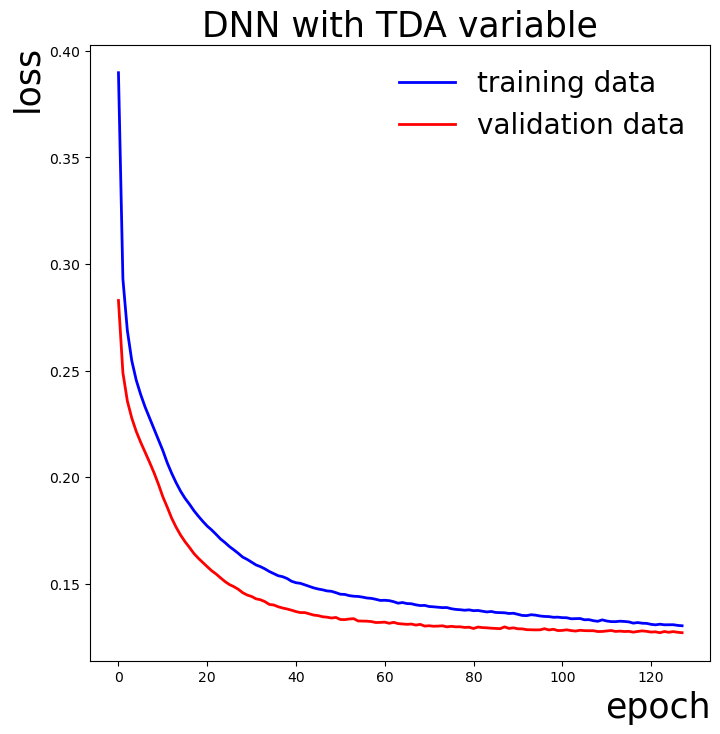

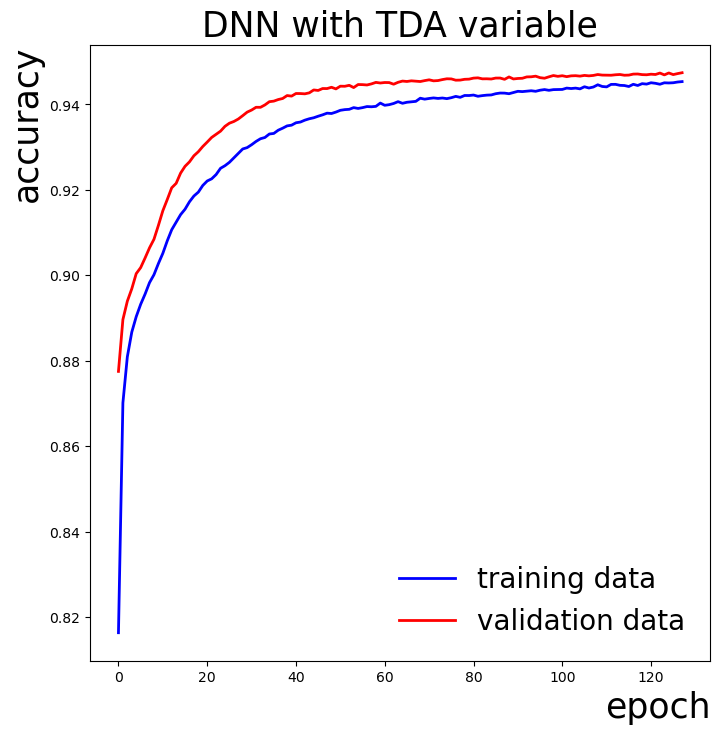

In [6]:
### plot learning curve

fig, ax = plt.subplots(1,1, figsize=(8,8))
plt.plot(tr_model.history["loss"], label='training data',c='blue',linewidth = 2)
plt.plot(tr_model.history["val_loss"], label='validation data',c='red',linewidth = 2)
plt.title("DNN with TDA variable", fontsize=25)
ax.set_ylabel('loss', fontsize=25,horizontalalignment='right',y=1)
ax.set_xlabel('epoch', fontsize=25,horizontalalignment='right',x=1)
# plt.yscale("log")
plt.legend(loc='best', prop={'size':20}, edgecolor = "w",fancybox=False, framealpha=0)
plt.show()

fig, ax = plt.subplots(1,1, figsize=(8,8))
plt.plot(tr_model.history["accuracy"], label='training data',c='blue',linewidth = 2)
plt.plot(tr_model.history["val_accuracy"], label='validation data',c='red',linewidth = 2)
plt.title("DNN with TDA variable", fontsize=25)
ax.set_ylabel('accuracy', fontsize=25,horizontalalignment='right',y=1)
ax.set_xlabel('epoch', fontsize=25,horizontalalignment='right',x=1)
# plt.yscale("log")
plt.legend(loc='best', prop={'size':20}, edgecolor = "w",fancybox=False, framealpha=0)
plt.show()

In [7]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:2976.7716(s)


In [8]:
### save the model ###

model.save("/root/data/mucollider/two_boosted/3TeV/model_mucollider_woTDA.h5")

/root/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [9]:
### model test ###

HLtest = []
LLtest = []
targettest = []
prediction = []

processes = ["hhvv", "hhmumu", "jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
event_num = [147518, 143791, 35834, 35591, 39064, 50582, 99709, 60870, 120594, 132700]
Xsection = [4.0360050e-02, +3.3945676e-03, 1.345150e+01, 4.423600e+00, 2.325600e+00, 1.506969e+02, 1.224052e+01, 9.618000e+00, 6.473005e+00, 7.4722023e-01]     ### unit: fb
simulation_num = 500000
Luminosity = 1000   ### unit: fb^-1

count = 0
for process in processes:
    HLtest.append(HLdata[count:count+event_num[processes.index(process)]])
    LLtest.append(LLdata[count:count+event_num[processes.index(process)]])
    targettest.append(target[count:count+event_num[processes.index(process)]])
    prediction.append(model.predict([HLtest[-1], LLtest[-1]]))
    count += event_num[processes.index(process)]

4141/4141 [==============================] - 8s 2ms/step


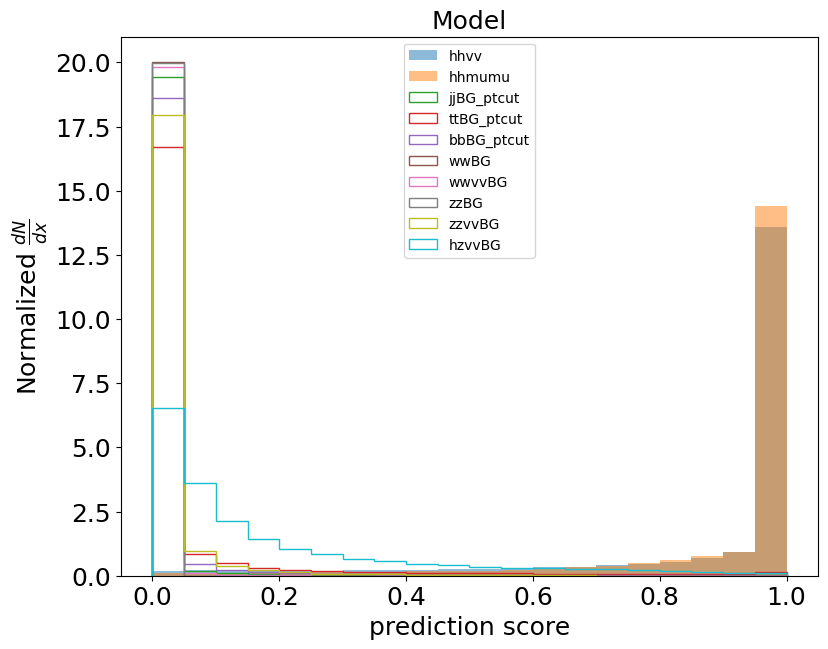

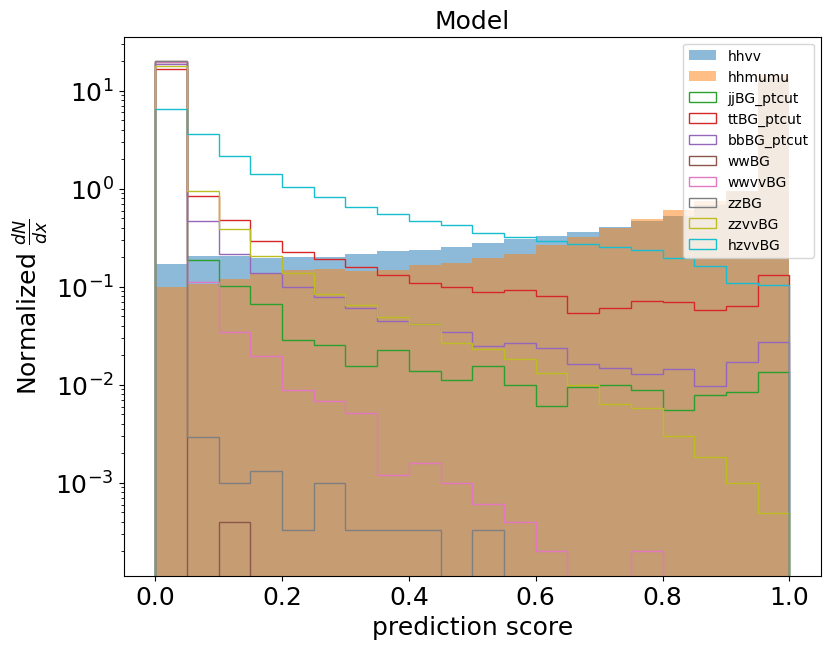

In [10]:
##### plot the prediction histogram #####

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for process in processes:
    plt.hist(prediction[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
# plt.yscale("log")
plt.title("Model", fontsize=18)
plt.legend(loc='best')
plt.show()

plt.figure(1, figsize=(9,7))
bins = np.linspace(0,1,21)
for process in processes:
    plt.hist(prediction[processes.index(process)], bins=bins, label=process, histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"Normalized $\frac{dN}{dx}$", fontsize=18)
plt.yscale("log")
plt.title("Model", fontsize=18)
plt.legend(loc='best')
plt.show()

In [11]:
### Do the score cut ###

score_cuts = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999]

for score_cut in score_cuts:
    print("In score cut", score_cut)

    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction[processes.index(process)]>=score_cut)[0])
    print("Number before ML: ", event_num)
    print("Number after  ML: ", num_afterML)
    
    ### calculate significance ###
    
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
        
    def significance(s,b):
        return np.sqrt(2*((s+b)*np.log(1+s/b)-s))
    
    z = significance(s,b)
    print("signal events:", s)
    print("background events:", b)
    print("significance:", z)
    print("\n")

In score cut 0.5
Number before ML:  [147518, 143791, 35834, 35591, 39064, 50582, 99709, 60870, 120594, 132700]
Number after  ML:  [131858, 133722, 171, 1374, 366, 0, 7, 1, 499, 15305]
signal events: 11.5514476830144
background events: 47.9818785103
significance: 1.6066461057922967


In score cut 0.7
Number before ML:  [147518, 143791, 35834, 35591, 39064, 50582, 99709, 60870, 120594, 132700]
Number after  ML:  [122438, 126473, 97, 809, 187, 0, 1, 0, 111, 7053]
signal events: 10.741849899949601
background events: 22.63852691438
significance: 2.107250260537637


In score cut 0.8
Number before ML:  [147518, 143791, 35834, 35591, 39064, 50582, 99709, 60870, 120594, 132700]
Number after  ML:  [116044, 120109, 63, 574, 133, 0, 0, 0, 38, 3811]
signal events: 10.182519524136799
background events: 13.579052373060001
significance: 2.495220056805084


In score cut 0.9
Number before ML:  [147518, 143791, 35834, 35591, 39064, 50582, 99709, 60870, 120594, 132700]
Number after  ML:  [107107, 110326, 

/tmp/ipykernel_1254/3436209754.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(2*((s+b)*np.log(1+s/b)-s))


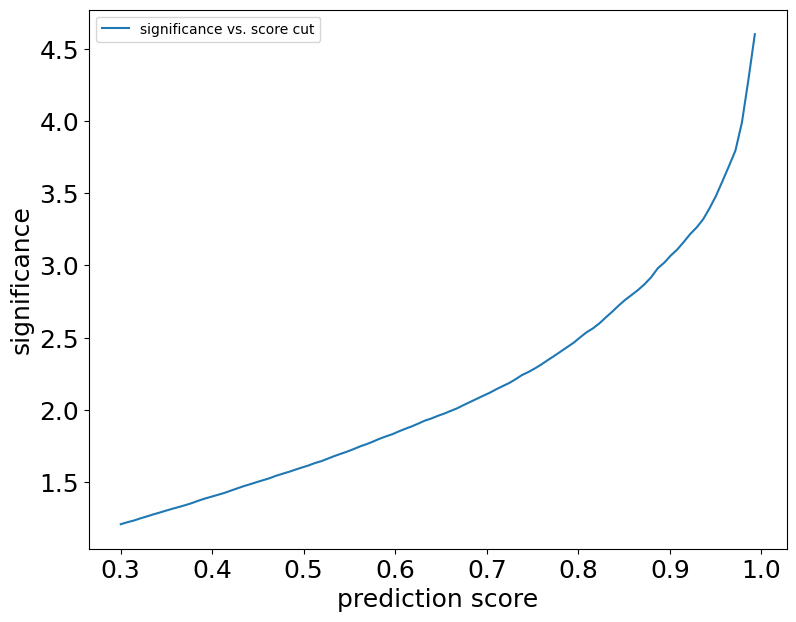

In [12]:
scores = np.linspace(0.3, 1, 100)
z_line = []

def significance(s,b):
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

for score in scores:
    num_afterML = []
    for process in processes: num_afterML.append(sum(prediction[processes.index(process)]>=score)[0])
    s, b = 0, 0
    for process in processes[0:2]:
        s += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    for process in processes[2:]:
        b += Luminosity * Xsection[processes.index(process)] * (num_afterML[processes.index(process)]/simulation_num)
    
    z_line.append(significance(s,b))

plt.figure(1, figsize=(9,7))
plt.plot(scores, z_line, label='significance vs. score cut')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"prediction score", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.legend(loc='best')
plt.show()

high level influence:  0.05773111
low  level influence:  0.053648673


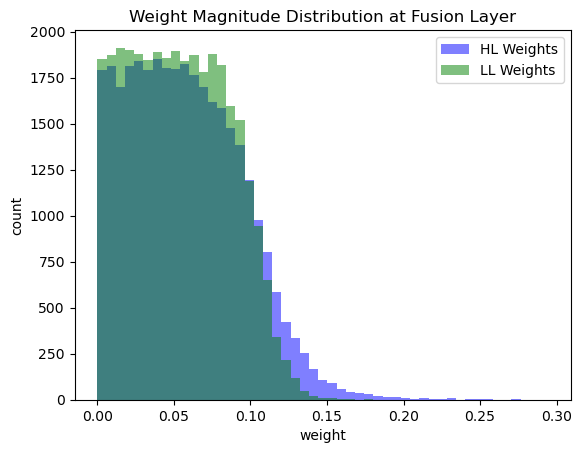

In [13]:
### check which part of model is more important ###

weights, biases = model.get_layer('dense_4').get_weights()
hl_influence = np.mean(np.abs(weights[:128, :]))
ll_influence = np.mean(np.abs(weights[128:, :]))
print("high level influence: ", hl_influence)
print("low  level influence: ", ll_influence)

weights, _ = model.get_layer('dense_4').get_weights()

hl_weights = np.abs(weights[:128, :]).flatten()
ll_weights = np.abs(weights[128:, :]).flatten()

bins = np.linspace(0,max(hl_weights), 50)
plt.hist(hl_weights, bins=bins, alpha=0.5, label='HL Weights', color='blue')
plt.hist(ll_weights, bins=bins, alpha=0.5, label='LL Weights', color='green')
plt.title('Weight Magnitude Distribution at Fusion Layer')
plt.xlabel('weight')
plt.ylabel('count')
plt.legend()
plt.show()

In [14]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:3155.1664(s)
